In [7]:
import optuna

study = optuna.load_study(
    study_name='rollout_v2',
    storage='sqlite:///../optuna_rollout_v2.db'
)

# Completed trials only
df = study.trials_dataframe()
df_done = df[df['state'] == 'COMPLETE'].sort_values('value')

# Parameter importance
optuna.visualization.plot_param_importances(study).show()

# Optimization history
optuna.visualization.plot_optimization_history(study).show()

# Slice plot (each param vs objective)
optuna.visualization.plot_slice(study).show()

In [8]:
import sys
sys.path.append('..')

import json, torch
from torch import nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from model_stuff import Predictor
from Rollout import train_rollout
from CoupledModel import CoupledModel

best = study.best_params
print(json.dumps(best, indent=2))

{
  "lag": 150,
  "train_horizon": 80,
  "transition_config": "100_7",
  "transition_prob": 0.7,
  "loss": "mse",
  "dropout_AMOC": 0.2353397597713059,
  "lr_AMOC": 0.0008843045111754514,
  "dropout_SFWF": 0.11139491393570292,
  "lr_SFWF": 0.00010615716591614097,
  "dropout_PD_200m": 0.043083152033888766,
  "lr_PD_200m": 0.0011769713786803253
}


In [10]:
model_vars = ['AMOC', 'SFWF', 'PD_200m']
features   = {name: [v for v in model_vars if v != name] for name in model_vars}
n_features = len(model_vars) - 1

train_cut_1 = 5000
train_cut_2 = 11000
device      = 'cpu'

X_df     = pd.read_csv('../../data/CESMDataset_Try.csv')
train_idx = list(range(train_cut_1)) + list(range(train_cut_2, len(X_df)))

scalers  = {}
X_scaled = X_df[model_vars].copy().astype(float)
for var in model_vars:
    sc = StandardScaler().fit(X_df[var].values[train_idx].reshape(-1, 1))
    X_scaled[var] = sc.transform(X_df[var].values.reshape(-1, 1))
    scalers[var] = sc

lag           = best['lag']
train_horizon = 100

models = {
    name: Predictor(
        n_features=n_features,
        hidden_size=64,
        num_layers=1,
        dropout=best[f'dropout_{name}'],
    ).to(device)
    for name in model_vars
}

lrs = {name: best[f'lr_{name}'] for name in model_vars}

In [11]:
transition_prob = 0.8
threshold_scaled = 7.0 / scalers['AMOC'].scale_[0]
search_ahead = 100

train_losses = train_rollout(
    X_scaled, 
    train_cut_1, 
    train_cut_2, 
    transition_prob, 
    threshold_scaled, 
    search_ahead,
    models, 
    features,
    train_steps=500,
    lag=lag,
    train_horizon=100,
    loss_fn=nn.MSELoss(),
    lrs=lrs,
)


In [12]:
trained_models = {}

for name in model_vars:
    feature_cols = features[name]
    x_sc = StandardScaler().fit(X_df[feature_cols].values[train_idx])
    
    trained_models[name] = {
        'model':    models[name],
        'x_scaler': x_sc,
        'y_scaler': scalers[name],
    }

coupled = CoupledModel.from_trained(trained_models)

In [24]:
horizon = 1
rho = 0.9
k = 0.3

start_idx = 7000
models = ['AMOC', 'SFWF', 'PD_200m']
features = {
    'AMOC': ['SFWF', 'PD_200m'],
    'SFWF': ['AMOC', 'PD_200m'],
    'PD_200m': ['SFWF', 'AMOC'],
}
steps = 5000
threshold = 13

predictions = coupled.predict(device, X_df, start_idx, lag, horizon, models, features, steps, threshold, rho, k)

/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


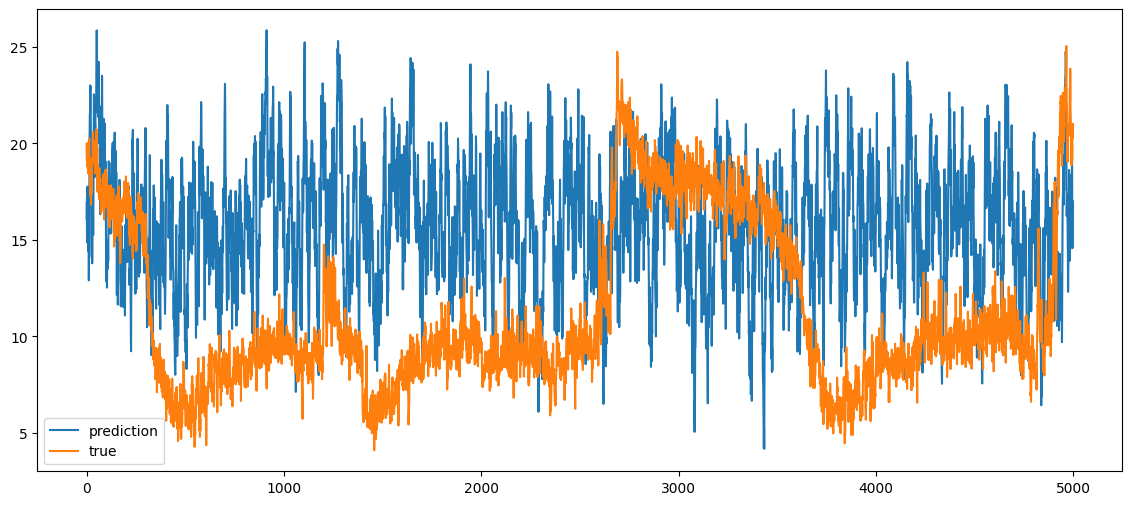

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, predictions['AMOC'], label = 'prediction')
plt.plot(x, X_df['AMOC'][start_idx:start_idx+5000], label = 'true')
plt.legend()